In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
%matplotlib widget

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Source Han Sans CN']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子以确保可重复性
np.random.seed(42)


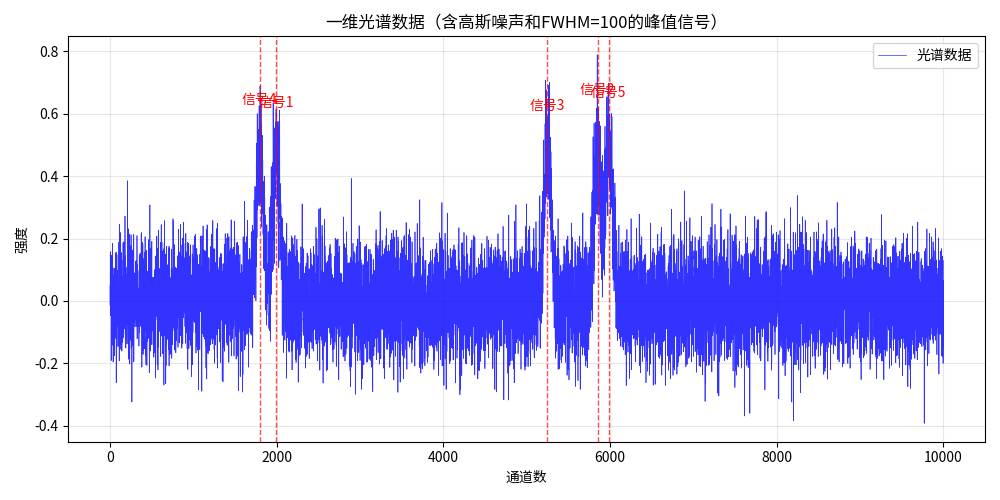

Mean = 0.02632483597288736
std = 0.13753658257924


In [2]:

# 生成10000个数据点，填充mu=0.1, sigma=0.1的高斯噪声
data_length = 10000
mu_data = 0
sigma_data = 0.1

# 生成基础高斯噪声
spectrum = np.random.normal(mu_data, sigma_data, data_length)

# 定义信号参数
fwhm = 100  # 半高全宽为100个通道
peak_height = 5 * sigma_data  # 峰值高度为5σ
signal_mu = peak_height  # 信号峰值

# 根据FWHM计算高斯函数的sigma
# FWHM = 2.355 * sigma (对于高斯分布)
sigma_gaussian = fwhm / 2.355

# 选择5个位置插入高斯峰值信号
signal_positions = []
for i in range(5):
    # 随机选择信号中心位置，确保不超出边界（考虑FWHM宽度）
    center = np.random.randint(fwhm, data_length - fwhm)
    signal_positions.append(center)

    # 生成高斯峰值信号（覆盖±3sigma范围，确保包含主要信号）
    signal_range = int(3 * sigma_gaussian)  # 覆盖±3sigma
    x = np.arange(-signal_range, signal_range + 1)

    # 高斯函数：A * exp(-(x-mu)^2/(2*sigma^2))
    gaussian_signal = peak_height * np.exp(-x**2 / (2 * sigma_gaussian**2))

    # 将信号插入到光谱中
    start_idx = center - signal_range
    end_idx = center + signal_range + 1
    spectrum[start_idx:end_idx] += gaussian_signal

# 创建横坐标（通道数）
channels = np.arange(1, data_length + 1)

# 绘制完整光谱图
plt.figure(figsize=(10, 5))
plt.plot(channels, spectrum, 'b-', linewidth=0.5, alpha=0.8, label='光谱数据')

# 标记信号位置
for i, pos in enumerate(signal_positions):
    plt.axvline(x=pos, color='red', linestyle='--', alpha=0.7, linewidth=1)
    plt.text(pos, spectrum[pos] + 0.2, f'信号{i+1}',
            ha='center', va='bottom', fontsize=10, color='red')

plt.xlabel('通道数')
plt.ylabel('强度')
plt.title(f'一维光谱数据（含高斯噪声和FWHM={fwhm}的峰值信号）')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Mean =", spectrum.mean())
print("std =", spectrum.std())

Best value of x = 3.0
N(>xσ) / N(total) = 0.0194


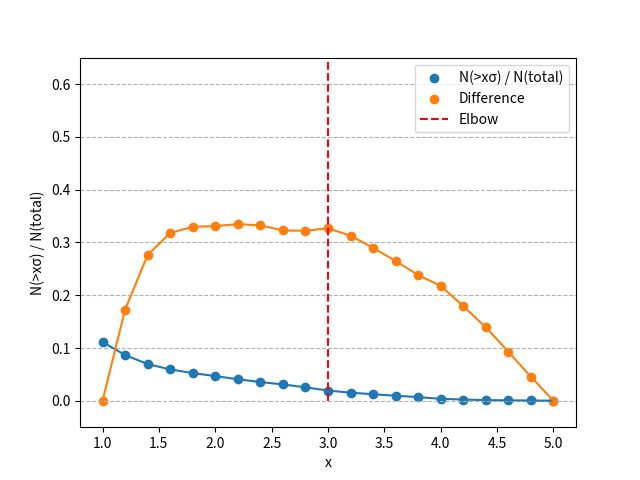

In [3]:
from kneed import KneeLocator

def test_sigma_clip(test=False):
    if test == True:
        # use knee/elbow value to find the best s value
        s_ = np.arange(1, 5.2, 0.2)
        y_ = []

        for i in range(len(s_)):
            upper_bound = spectrum.mean() + spectrum.std() * s_[i]
            mask = spectrum > upper_bound  # mask == True: v > sσ
            y_.append(
                np.count_nonzero(mask) / np.count_nonzero(spectrum)
            )  # N(True) / N(total)

        kneedle = KneeLocator(
            s_, y_, S=1.0, curve="convex", direction="decreasing"
        )  # knee/elbow value
        print("Best value of x =", round(kneedle.elbow, 4))
        print("N(>xσ) / N(total) =", round(kneedle.elbow_y, 4))

        # plot the results as in kneedle.plot_knee()
        fig = plt.figure()
        plt.scatter(s_, y_, label="N(>xσ) / N(total)")
        plt.scatter(s_, kneedle.y_difference, label="Difference")
        plt.plot(s_, y_)
        plt.plot(s_, kneedle.y_difference)
        plt.ylim(-0.05, 0.65)
        plt.vlines(round(kneedle.elbow, 3), 0, 1, ls="--", colors="red", label="Elbow")
        plt.xlabel("x")
        plt.ylabel("N(>xσ) / N(total)")
        plt.grid(axis="y", ls="--")
        plt.legend()
        plt.show()
        return kneedle.elbow
    else:
        # if (usually) the s value found this way is too small, choose s = 3
        return 3


s = test_sigma_clip(test=True)

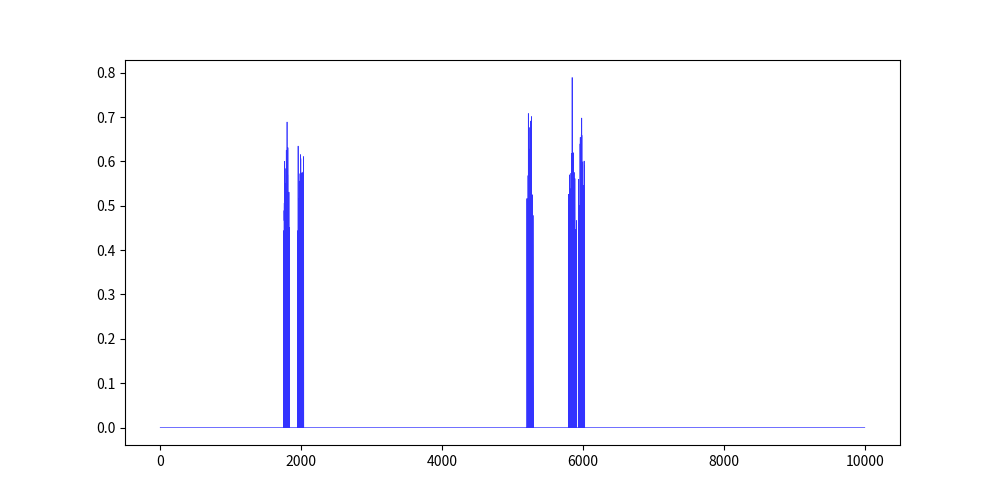

In [4]:
# 将你一开始生成的spectrum一维数据，所有小于mu+2sigma的数据都设为NaN，得到spectrum_mask
spectrum_mask = spectrum.copy()
upper_bound = spectrum.mean() + spectrum.std() * s
spectrum_mask[spectrum < upper_bound] = 0

# 绘制完整光谱图
plt.figure(figsize=(10, 5))
plt.plot(channels, spectrum_mask, 'b-', linewidth=0.5, alpha=0.8, label='光谱数据')
plt.show()

In [5]:
print(np.sum(spectrum_mask) / 5)
print(np.sum(spectrum) / 5)
print(peak_height * sigma_gaussian * np.sqrt(2*np.pi))

20.485638618812125
52.64967194577472
53.219283962441615


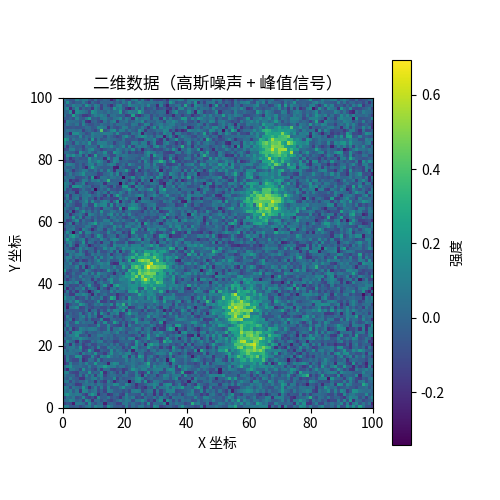

Mean = 0.02632483597288736
std = 0.13753658257924


In [6]:
# 生成100x100的二维数据，填充mu=0.1, sigma=0.1的高斯噪声
shape = (100, 100)
mu_data = 0
sigma_data = 0.1

# 生成基础高斯噪声
data = np.random.normal(mu_data, sigma_data, shape)

# 定义信号参数
fwhm = 10  # 半高全宽为10像素
peak_height = 5 * sigma_data  # 峰值高度为5σ

# 根据FWHM计算高斯函数的sigma
sigma_gaussian = fwhm / (2 * np.sqrt(2 * np.log(2)))  # 精确的高斯FWHM公式

# 选择10个位置插入高斯峰值信号
signal_centers = []
for i in range(5):
    # 随机选择信号中心位置，确保不超出边界
    center_x = np.random.randint(fwhm, shape[0] - fwhm)
    center_y = np.random.randint(fwhm, shape[1] - fwhm)
    signal_centers.append((center_x, center_y))

    # 生成二维高斯峰值
    x = np.arange(shape[0])
    y = np.arange(shape[1])
    X, Y = np.meshgrid(x, y, indexing='ij')

    # 二维高斯函数
    gaussian_signal = peak_height * np.exp(-((X - center_x)**2 + (Y - center_y)**2) / (2 * sigma_gaussian**2))

    # 将信号添加到数据中
    data += gaussian_signal

# 绘制二维图像
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# 1. 主二维图像
im1 = axes.imshow(data, cmap='viridis', origin='lower',
                       extent=[0, shape[1], 0, shape[0]])
axes.set_xlabel('X 坐标')
axes.set_ylabel('Y 坐标')
axes.set_title('二维数据（高斯噪声 + 峰值信号）')
plt.colorbar(im1, ax=axes, label='强度')
plt.show()

print("Mean =", spectrum.mean())
print("std =", spectrum.std())

Best value of x = 2.2
N(>xσ) / N(total) = 0.0326


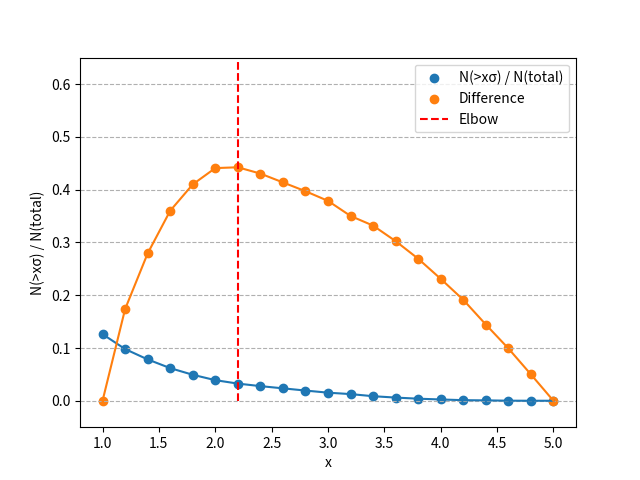

In [7]:
from kneed import KneeLocator

def test_sigma_clip(test=False):
    if test == True:
        # use knee/elbow value to find the best s value
        s_ = np.arange(1, 5.2, 0.2)
        y_ = []

        for i in range(len(s_)):
            upper_bound = data.mean() + data.std() * s_[i]
            mask = data > upper_bound  # mask == True: v > sσ
            y_.append(
                np.count_nonzero(mask) / np.count_nonzero(data)
            )  # N(True) / N(total)

        kneedle = KneeLocator(
            s_, y_, S=1.0, curve="convex", direction="decreasing"
        )  # knee/elbow value
        print("Best value of x =", round(kneedle.elbow, 4))
        print("N(>xσ) / N(total) =", round(kneedle.elbow_y, 4))

        # plot the results as in kneedle.plot_knee()
        fig = plt.figure()
        plt.scatter(s_, y_, label="N(>xσ) / N(total)")
        plt.scatter(s_, kneedle.y_difference, label="Difference")
        plt.plot(s_, y_)
        plt.plot(s_, kneedle.y_difference)
        plt.ylim(-0.05, 0.65)
        plt.vlines(round(kneedle.elbow, 3), 0, 1, ls="--", colors="red", label="Elbow")
        plt.xlabel("x")
        plt.ylabel("N(>xσ) / N(total)")
        plt.grid(axis="y", ls="--")
        plt.legend()
        plt.show()
        return kneedle.elbow
    else:
        # if (usually) the s value found this way is too small, choose s = 3
        return 3


s = test_sigma_clip(test=True)

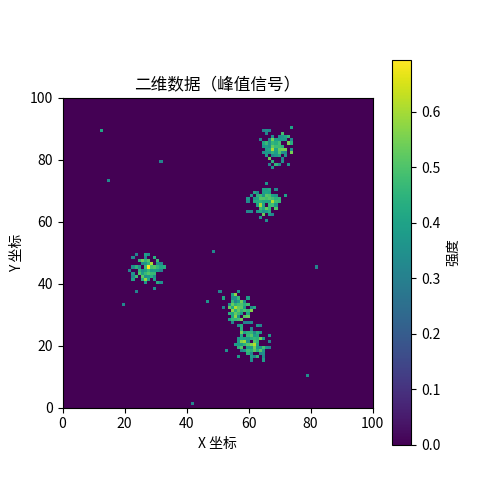

In [8]:
# 将你一开始生成的spectrum一维数据，所有小于mu+2sigma的数据都设为NaN，得到spectrum_mask
data_mask = data.copy()
upper_bound = data.mean() + data.std() * s
data_mask[data < upper_bound] = 0

# 绘制完整光谱图
# 绘制二维图像
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# 1. 主二维图像
im1 = axes.imshow(data_mask, cmap='viridis', origin='lower',
                       extent=[0, shape[1], 0, shape[0]])
axes.set_xlabel('X 坐标')
axes.set_ylabel('Y 坐标')
axes.set_title('二维数据（峰值信号）')
plt.colorbar(im1, ax=axes, label='强度')

In [9]:
print(np.sum(data_mask) / 5)
print(np.sum(data) / 5)
print(peak_height * sigma_gaussian**2 * 2*np.pi)

27.298257970689498
56.12640991737597
56.65450177283993


In [10]:
# 生成100x100x100的三维数据，填充sigma=0.1的高斯噪声
shape = (100, 100, 100)
mu_noise = 0  # 平均值为0
sigma_noise = 0.1

# 生成基础高斯噪声
data_3d = np.random.normal(mu_noise, sigma_noise, shape)

# 定义信号参数
peak_height = 5 * sigma_noise  # 峰值高度为5σ
# 根据FWHM计算高斯函数的sigma
# FWHM = 2.355 * sigma (对于高斯分布)
fwhm = 10
sigma_gaussian = fwhm / 2.355
radius = sigma_gaussian * 3  # 球体半径

print(f"球体半径: {radius} 体素")
print(f"高斯sigma: {sigma_gaussian:.2f} 体素")
print(f"信号峰值高度: {peak_height:.4f} ({peak_height/sigma_noise:.1f}σ)")

def create_3d_gaussian(shape, center, sigma, amplitude):
    """创建三维高斯峰值"""
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    distance_sq = (x - center[2])**2 + (y - center[1])**2 + (z - center[0])**2
    gaussian = amplitude * np.exp(-distance_sq / (2 * sigma**2))
    return gaussian

# 选择10个位置插入三维高斯峰值信号
signal_centers = []
for i in range(5):
    # 随机选择信号中心位置，确保不超出边界
    center_x = np.random.randint(radius, shape[0] - radius)
    center_y = np.random.randint(radius, shape[1] - radius)
    center_z = np.random.randint(radius, shape[2] - radius)
    center = (center_x, center_y, center_z)
    signal_centers.append(center)

    # 生成三维高斯峰值
    gaussian_signal = create_3d_gaussian(shape, center, sigma_gaussian, peak_height)

    # 将信号添加到数据中
    data_3d += gaussian_signal

print(f"\n三维数据生成完成!")
print(f"数据形状: {data_3d.shape}")
print(f"信号数量: {len(signal_centers)}")
print(f"信号中心位置: {signal_centers}")

球体半径: 12.738853503184714 体素
高斯sigma: 4.25 体素
信号峰值高度: 0.5000 (5.0σ)

三维数据生成完成!
数据形状: (100, 100, 100)
信号数量: 5
信号中心位置: [(83, 21, 42), (18, 26, 30), (32, 37, 75), (47, 13, 33), (33, 84, 47)]


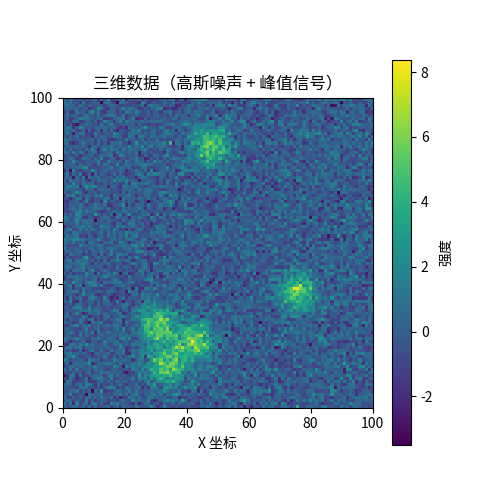

Mean = 0.02632483597288736
std = 0.13753658257924


In [11]:
moment_0 = np.sum(data_3d, axis=0)

# 绘制二维图像
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# 1. 主二维图像
im1 = axes.imshow(moment_0, cmap='viridis', origin='lower',
                       extent=[0, shape[1], 0, shape[0]])
axes.set_xlabel('X 坐标')
axes.set_ylabel('Y 坐标')
axes.set_title('三维数据（高斯噪声 + 峰值信号）')
plt.colorbar(im1, ax=axes, label='强度')
plt.show()

print("Mean =", spectrum.mean())
print("std =", spectrum.std())

Best value of x = 2.2
N(>xσ) / N(total) = 0.0155


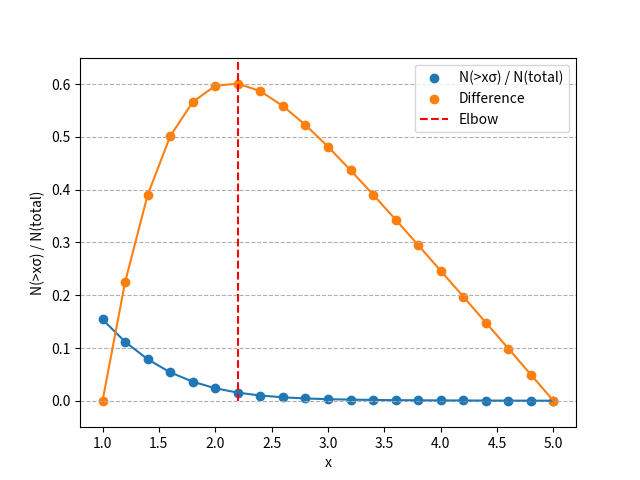

In [12]:
from kneed import KneeLocator

def test_sigma_clip(test=False):
    if test == True:
        # use knee/elbow value to find the best s value
        s_ = np.arange(1, 5.2, 0.2)
        y_ = []

        for i in range(len(s_)):
            upper_bound = data_3d.mean() + data_3d.std() * s_[i]
            mask = data_3d > upper_bound  # mask == True: v > sσ
            y_.append(
                np.count_nonzero(mask) / np.count_nonzero(data_3d)
            )  # N(True) / N(total)

        kneedle = KneeLocator(
            s_, y_, S=1.0, curve="convex", direction="decreasing"
        )  # knee/elbow value
        print("Best value of x =", round(kneedle.elbow, 4))
        print("N(>xσ) / N(total) =", round(kneedle.elbow_y, 4))

        # plot the results as in kneedle.plot_knee()
        fig = plt.figure()
        plt.scatter(s_, y_, label="N(>xσ) / N(total)")
        plt.scatter(s_, kneedle.y_difference, label="Difference")
        plt.plot(s_, y_)
        plt.plot(s_, kneedle.y_difference)
        plt.ylim(-0.05, 0.65)
        plt.vlines(round(kneedle.elbow, 3), 0, 1, ls="--", colors="red", label="Elbow")
        plt.xlabel("x")
        plt.ylabel("N(>xσ) / N(total)")
        plt.grid(axis="y", ls="--")
        plt.legend()
        plt.show()
        return kneedle.elbow
    else:
        # if (usually) the s value found this way is too small, choose s = 3
        return 3


s = test_sigma_clip(test=True)

In [17]:
data_3d_mask = data_3d.copy()
upper_bound = data_3d.mean() + data_3d.std() * 2.2
data_3d_mask[data_3d < upper_bound] = 0

In [21]:
upper_bound

np.float64(0.22884907299496388)

In [18]:
print(np.sum(data_3d_mask) / 5)
print(np.sum(data_3d) / 5)
print(peak_height * sigma_gaussian**3 * (2*np.pi)**1.5)

872.5145460856689
599.8611364583601
602.9302483335928


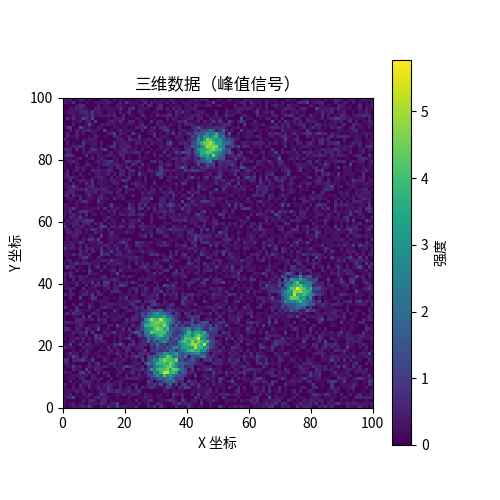

Mean = 0.02632483597288736
std = 0.13753658257924


In [16]:
moment_0_mask = np.sum(data_3d_mask, axis=0)

# 绘制二维图像
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# 1. 主二维图像
im1 = axes.imshow(moment_0_mask, cmap='viridis', origin='lower',
                       extent=[0, shape[1], 0, shape[0]])
axes.set_xlabel('X 坐标')
axes.set_ylabel('Y 坐标')
axes.set_title('三维数据（峰值信号）')
plt.colorbar(im1, ax=axes, label='强度')
plt.show()

print("Mean =", spectrum.mean())
print("std =", spectrum.std())